In [1]:
# Wolfram Language Imports
from wolframclient.evaluation import WolframLanguageSession
from wolframclient.language import wl, wlexpr
ws = WolframLanguageSession()

In [2]:
# Display Latex
from IPython.display import display, Math

# Display Plots
%matplotlib notebook
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [3]:
def print_tex(expr):
    """Prints an expression in latex"""
    display(Math(expr))

def print_wlresult(expr):
    """Prints a wolfram language result in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(expr)))
    display(Math(tex_expr))

def print_wlexpr(expr):
    """Prints a wolfram language expression in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(ws.evaluate(expr))))
    display(Math(tex_expr))

def print_wlexpr_latex(expr):
    """Prints a wolfram language expression in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(ws.evaluate(expr))))
    print(tex_expr)
    
def wc(expr):
    """Evaluates an expression, stores, and prints the result"""
    result = ws.evaluate(expr)
    save_expr_str = 'rrr = {}'.format(expr)
    ws.evaluate(save_expr_str)
    print_wlresult(ws.evaluate('rrr'))
    return result

def wplot(filename, command):
    export_expr = 'Export["{}", {}]'.format(filename, command)
    wc(export_expr)
    img = mpimg.imread(filename)
    imgplot = plt.imshow(img)
    plt.show()
    plt.axis('off')

## Matched Frequency Case

### Compute the Integrals for the Rising and Falling Side of the Compressed Pulse

In [4]:
wc('''
result1 = Integrate[Sin[w*u]*Sin[w*(u-t)], {u, 0, t+L}]
''')

<IPython.core.display.Math object>

Times[Rational[-1, 4], Power[Global`w, -1], Plus[Times[-2, Plus[Global`L, Global`t], Global`w, Cos[Times[Global`t, Global`w]]], Sin[Times[Global`t, Global`w]], Sin[Times[Plus[Times[2, Global`L], Global`t], Global`w]]]]

In [5]:
wc('''
result2 = Integrate[Sin[w*u]*Sin[w*(u-t)], {u, t, L}]
''')

<IPython.core.display.Math object>

Times[Rational[1, 4], Power[Global`w, -1], Plus[Times[2, Plus[Global`L, Times[-1, Global`t]], Global`w, Cos[Times[Global`t, Global`w]]], Sin[Times[Global`t, Global`w]], Sin[Times[Plus[Times[-2, Global`L], Global`t], Global`w]]]]

### Plot the Result at a Given Frequency and Length

<IPython.core.display.Javascript object>


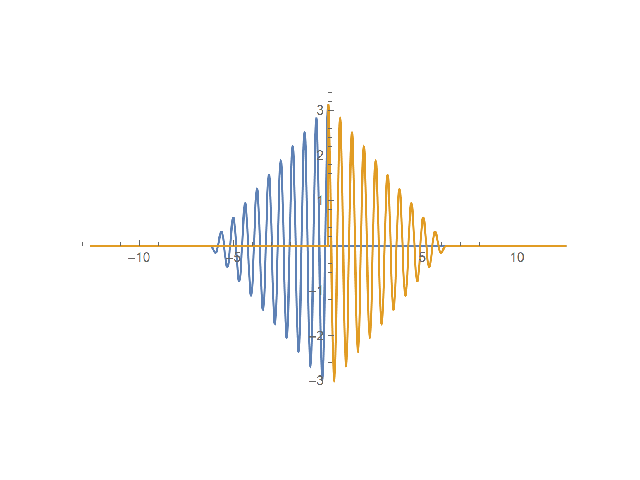

<IPython.core.display.Math object>

In [6]:
plt.figure()
wplot("figure1.png", '''
Plot[
{(HeavisideTheta[t + L] - HeavisideTheta[t]) * result1 /. w -> 10 /. L -> 2*Pi,
 (HeavisideTheta[t] - HeavisideTheta[t - L]) * result2 /. w -> 10 /. L -> 2*Pi
}, {t, -4*Pi, 4*Pi}, PlotRange -> All
]
''')

### Determine Peak Amplitude wrt. Length and Frequency

In [7]:
wc('''
amp = result1 /. t -> 0
''')

<IPython.core.display.Math object>

Times[Rational[-1, 4], Power[Global`w, -1], Plus[Times[-2, Global`L, Global`w], Sin[Times[2, Global`L, Global`w]]]]

### Plot Amplitude wrt. Length for Different Frequencies

<IPython.core.display.Javascript object>


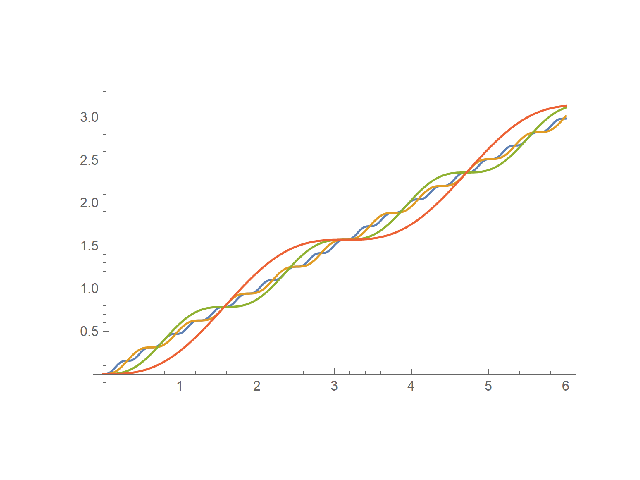

<IPython.core.display.Math object>

In [8]:
plt.figure()
wplot("figure2.png", '''
Plot[
{amp /. w -> 10,
 amp /. w -> 5,
 amp /. w -> 2,
 amp /. w -> 1
}, {L, 0, 6}
]
''')

### Plot Amplitude to Length Ratios for Different Frequencies

<IPython.core.display.Javascript object>


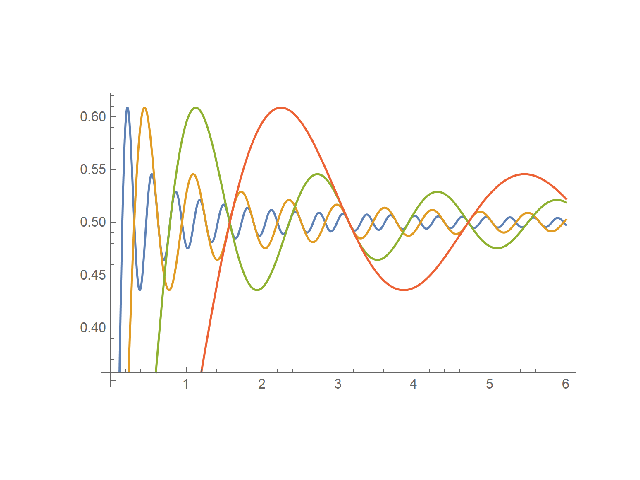

<IPython.core.display.Math object>

In [9]:
plt.figure()
wplot("figure3.png", '''
Plot[
{amp / L /. w -> 10,
 amp / L /. w -> 5,
 amp / L /. w -> 2,
 amp / L /. w -> 1
}, {L, 0, 6}
]
''')

## Mismatched Frequency Case

In [18]:
wc('''
resultmm1 = Integrate[Sin[a*u]*Sin[b*(u-t)], {u, 0, t+L}]
''')

<IPython.core.display.Math object>

Times[Power[Plus[Power[Global`a, 2], Times[-1, Power[Global`b, 2]]], -1], Plus[Times[-1, Global`a, Cos[Times[Global`a, Plus[Global`L, Global`t]]], Sin[Times[Global`b, Global`L]]], Times[-1, Global`a, Sin[Times[Global`b, Global`t]]], Times[Global`b, Cos[Times[Global`b, Global`L]], Sin[Times[Global`a, Plus[Global`L, Global`t]]]]]]

In [17]:
wc('''
resultmm2 = Integrate[Sin[a*u]*Sin[b*(u-t)], {u, t, L}]
''')

<IPython.core.display.Math object>

Times[Rational[1, 2], Power[Plus[Global`a, Times[-1, Global`b]], -1], Power[Plus[Global`a, Global`b], -1], Plus[Times[-2, Global`b, Sin[Times[Global`a, Global`t]]], Times[Plus[Times[-1, Global`a], Global`b], Sin[Plus[Times[Plus[Global`a, Global`b], Global`L], Times[-1, Global`b, Global`t]]]], Times[Plus[Global`a, Global`b], Sin[Plus[Times[Global`a, Global`L], Times[-1, Global`b, Global`L], Times[Global`b, Global`t]]]]]]

### Plot Result at a Given Frequency Pair and Length

For slightly mismatched frequencies the peak becomes less pronounced.  For very mismatched frequencies the peak deteriorates into multiple sidelobes.

<IPython.core.display.Javascript object>


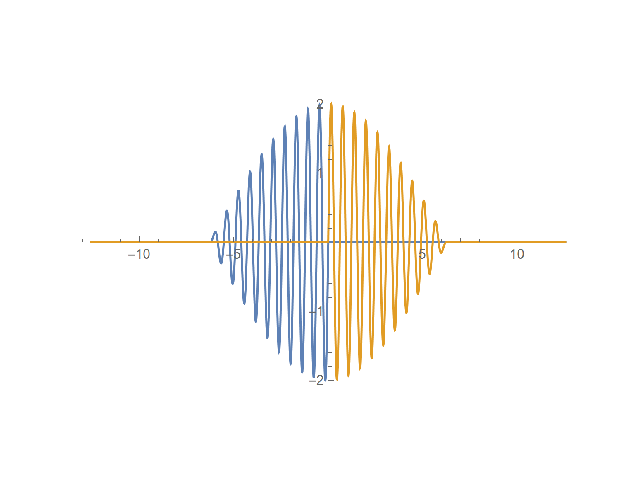

<IPython.core.display.Math object>

In [12]:
plt.figure()
wplot("figure4.png", '''
Plot[
{(HeavisideTheta[t + L] - HeavisideTheta[t]) * resultmm1 /. a -> 10 /. b -> 10.5 /. L -> 2*Pi,
 (HeavisideTheta[t] - HeavisideTheta[t - L]) * resultmm2 /. a -> 10 /. b -> 10.5 /. L -> 2*Pi
}, {t, -4*Pi, 4*Pi}, PlotRange -> All
]
''')

<IPython.core.display.Javascript object>


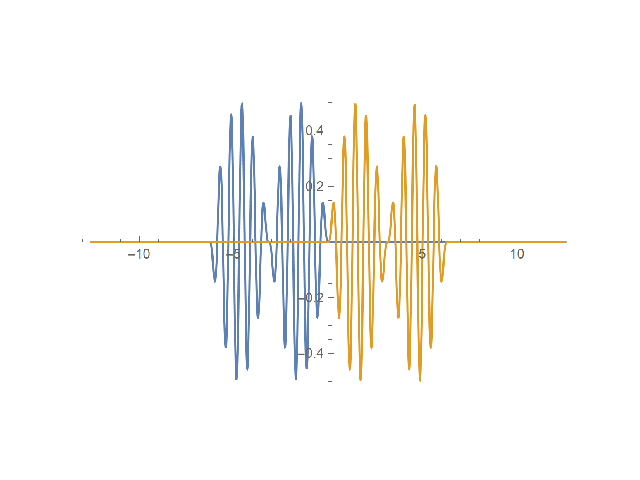

<IPython.core.display.Math object>

In [13]:
plt.figure()
wplot("figure5.png", '''
Plot[
{(HeavisideTheta[t + L] - HeavisideTheta[t]) * resultmm1 /. a -> 10 /. b -> 12 /. L -> 2*Pi,
 (HeavisideTheta[t] - HeavisideTheta[t - L]) * resultmm2 /. a -> 10 /. b -> 12 /. L -> 2*Pi
}, {t, -4*Pi, 4*Pi}, PlotRange -> All
]
''')

### Determine Peak Amplitude wrt. Length and Frequency Pair

In [14]:
wc('''
ampmm = FullSimplify[resultmm1 /. t -> 0]
''')

<IPython.core.display.Math object>

Times[Power[Plus[Power[Global`a, 2], Times[-1, Power[Global`b, 2]]], -1], Plus[Times[Global`b, Cos[Times[Global`b, Global`L]], Sin[Times[Global`a, Global`L]]], Times[-1, Global`a, Cos[Times[Global`a, Global`L]], Sin[Times[Global`b, Global`L]]]]]

## Plot Amplitude wrt. Frequency B for Different Frequency A Values

We can see the resonant frequency of each filter constructed.

<IPython.core.display.Javascript object>


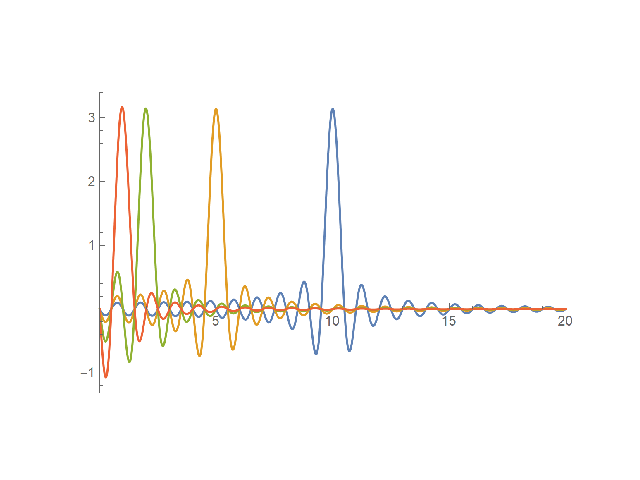

<IPython.core.display.Math object>

In [15]:
plt.figure()
wplot("figure2.png", '''
Plot[
{ampmm /. a -> 10 /. L -> 2*Pi,
 ampmm /. a -> 5  /. L -> 2*Pi,
 ampmm /. a -> 2  /. L -> 2*Pi,
 ampmm /. a -> 1  /. L -> 2*Pi
}, {b, 0, 20}, PlotRange -> All
]
''')

In [19]:
ws.stop()